In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import proplot as pplt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

from gcgnn.model_data import load_networkx_data
from gcgnn.plot import adjust_saturation, hex_to_rgba, adjacent_values

import matplotlib.pyplot as plt

COLORS = []
colors = pplt.Cycle("ggplot")
for color in colors:
    COLORS.append(color["color"])
colors = pplt.Cycle("default")
for color in colors:
    COLORS.append(color["color"])

pplt.rc["figure.facecolor"] = "white"

DATA_DIR="/scratch/gpfs/sj0161/delta_pattern/"
PLOT_DIR="/scratch/gpfs/sj0161/gcgnn/fig/"
TRAIN_RESULT_DIR = "/scratch/gpfs/sj0161/gcgnn/history/"
RESULT_DIR = "/scratch/gpfs/sj0161/gcgnn/result/"

topo_unique = ["linear", "cyclic", "star", "comb", "branch", "dendrimer"]

y_types    = ["mean", "std"]
split_types= [0, 1, 2]
patterns   = [0, 1]

### 1. GC-GNN Coefficients for Mean Rg2 Prediction across Molecular Weights

- pattern = 0, epsilon = 0.16, less solvophobic
- pattern = 1, epsilon = 1.0, more solvophobic
- pattern = 2, copolymer

In [4]:
from gcgnn.analysis import hyper_best, get_args
from gcgnn.model_data.load_data import load_data
from gcgnn.model_utils import evaluate_model
from torch_geometric.data import DataLoader
from tqdm import tqdm

In [5]:
coeff_path = "../result_temp/coefficient.pickle"

if os.path.exists(coeff_path):
    with open(coeff_path, "rb") as f:
        coeffs = pickle.load(f)
        patterns = pickle.load(f)
        topologies = pickle.load(f)
else:
    coeffs = []
    patterns = []
    topologies = []

    for split in [0, 1, 2]:
        v, y, file = hyper_best(
            TRAIN_RESULT_DIR, 
            methods=["GNN_Guided_Baseline_Simple"], 
            split_type=split,
            pattern=0,
            y_type="mean",
            scoring="RMSE"
        )

        args = get_args(file[0].split(".pickle")[0].split("/")[-1])
        args.MODEL_PATH = "/scratch/gpfs/sj0161/gcgnn/model/"
        args.DATA_DIR = DATA_DIR
        args.loss = "mse"

        (train_data, val_data, train_topo, val_topo), test_data, test_topo = load_data(args)
        train_loader = DataLoader(train_data, batch_size=args.batch_size, shuffle=False)
        val_loader = DataLoader(val_data, batch_size=args.batch_size, shuffle=False)
        test_loader = DataLoader(test_data, batch_size=args.batch_size, shuffle=False)
        args.train_loader = train_loader
        args.val_loader = val_loader
        args.test_loader = test_loader

        args.hyper_name = f"{args.model_type}_{args.split_type}_{args.pure_type}_{args.batch_size}_{args.lr}_{args.epochs}_{args.dim}_{args.y_type}_{args.loss}_{args.if_log}"

        model = evaluate_model(args)

        batch_coeffs = []
        for _, batch in tqdm(enumerate(args.train_loader), total=len(args.train_loader)):
            batch = batch.to(args.device)
            out = model(batch)
            a = out[1].cpu().detach().numpy()
            b = out[2].cpu().detach().numpy()
            batch_coeffs.append([a, b])

        batch_coeffs = np.concatenate(batch_coeffs, axis=1).squeeze()
        coeffs.append(batch_coeffs)

        batch_patterns = [train_data[i].pattern.cpu().numpy() for i in range(len(train_data))]
        patterns.append(np.array(batch_patterns))

        train_topo = np.array(train_topo)
        train_topo[train_topo == 'bottlebrush'] = "comb"
        train_topo[train_topo == 'stara'] = "star"
        topologies.append(train_topo)

    with open(coeff_path, "wb") as f:
        pickle.dump(coeffs, f)
        pickle.dump(patterns, f)
        pickle.dump(topologies, f)


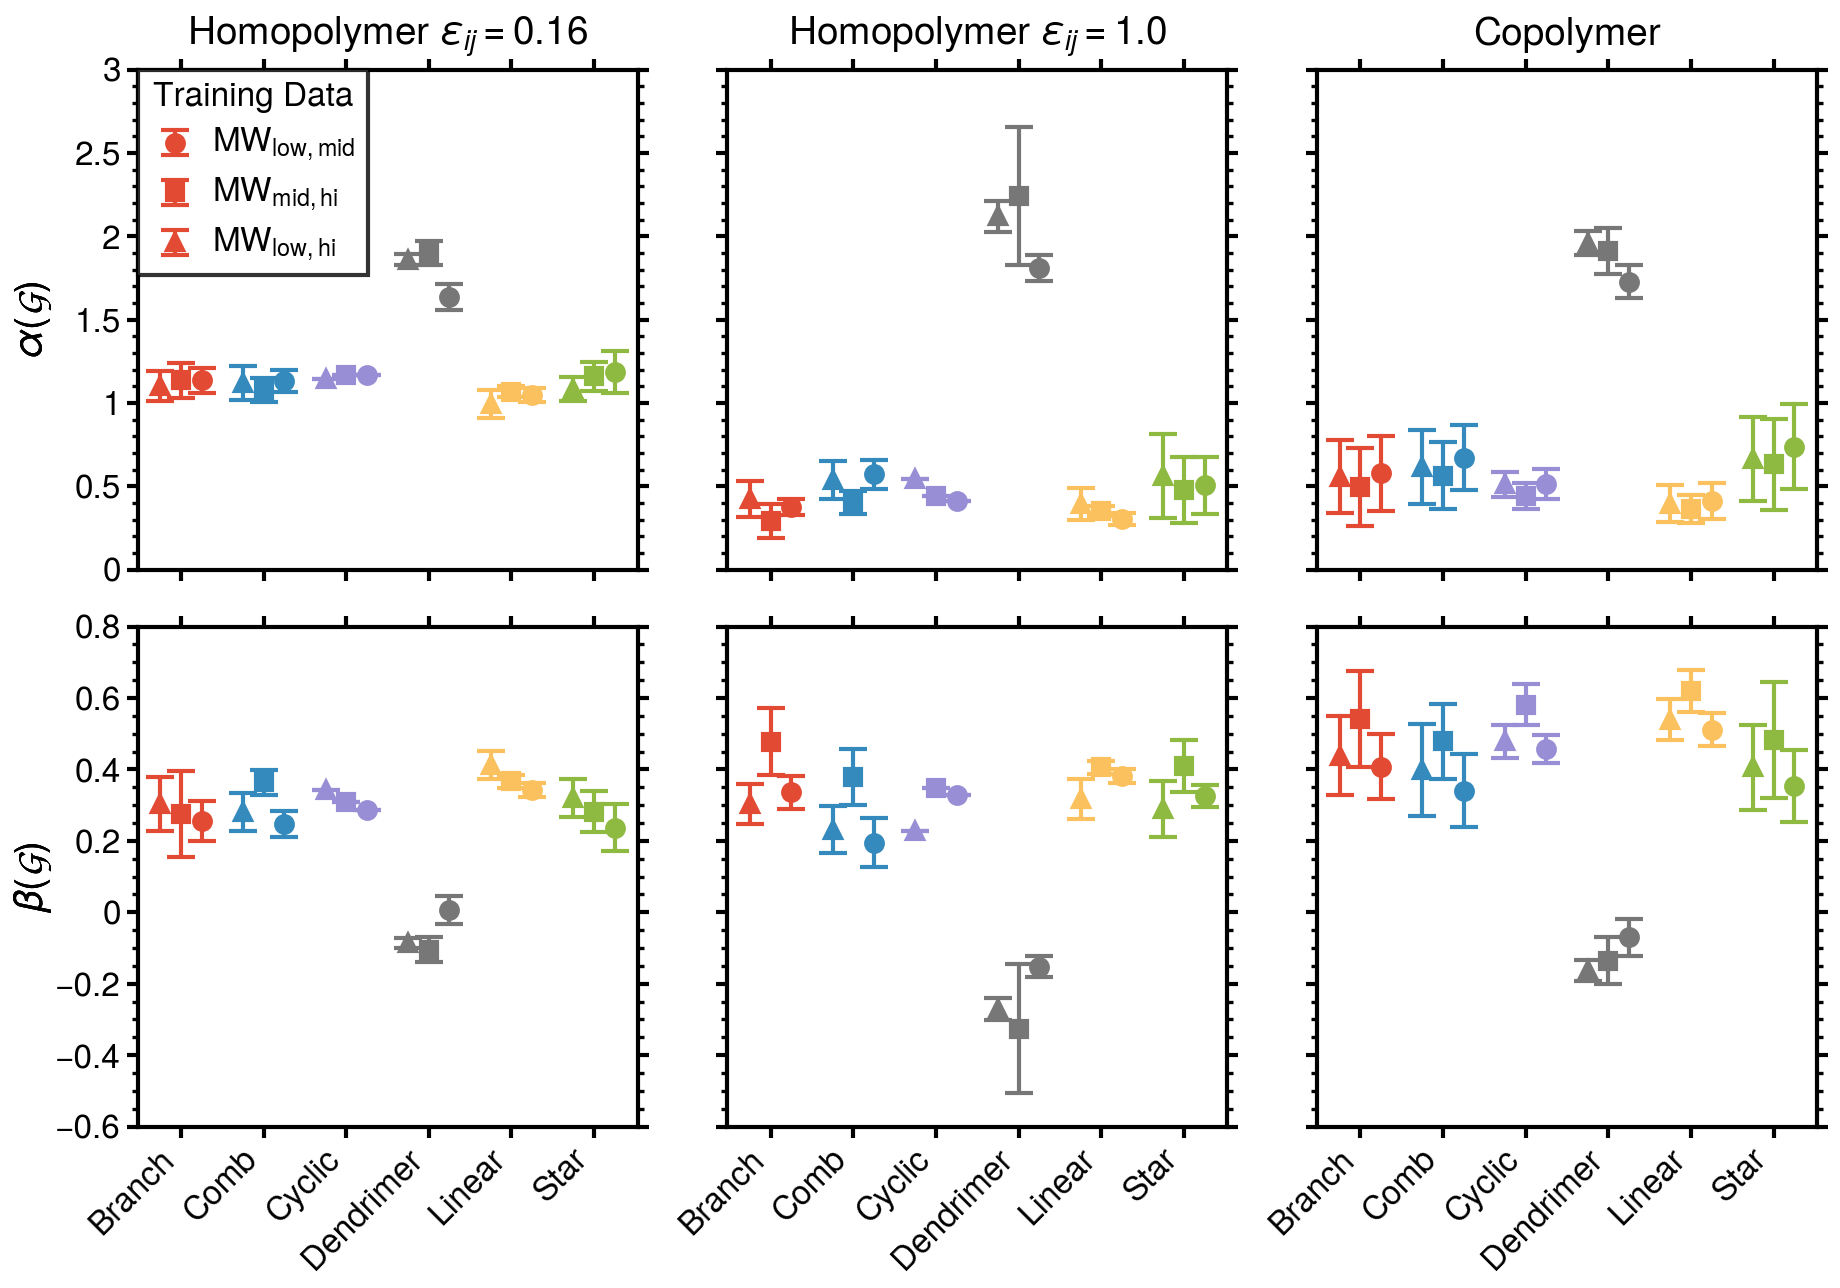

In [6]:
font_big = 14
font_small = 12
lw = 1.5
ncols = 3
nrows = 2

width = 7.5 / ncols
height = width

titles = [r"Homopolymer $\mathit{\varepsilon_{ij}=0.16}$", r"Homopolymer $\mathit{\varepsilon_{ij}=1.0}$", r"Copolymer"]
markers = ['o', 's', '^']
legends = [r'$MW_{low,mid}$', r'$MW_{mid,hi}$', r'$MW_{low,hi}$']
fig, axes = pplt.subplots(nrows=nrows, ncols=ncols, refwidth=width, refheight=height, sharey=True)

for row in range(nrows):
    for split in range(3):
        for ax_idx, pattern in enumerate([0, 1, 2]):
            ax = axes[row, ax_idx]
            unique_topos = np.unique(topologies[split])
            xtick_labels = []

            for topo_idx, topo in enumerate(unique_topos):
                idx = np.where((np.array(topologies[split]) == topo) & 
                               (np.array(patterns[split]) == pattern))[0]
                subset = coeffs[split][row][idx]
                if len(subset) > 0:
                    mean_val = np.mean(subset)
                    std_dev = np.std(subset)
                    x_pos = topo_idx - split * 0.25 - 0.25
                    ax.errorbar(
                        x_pos, mean_val, yerr=std_dev, fmt=markers[split],
                        color=COLORS[topo_idx], label=legends[split] if topo_idx == 0 else None,
                        capsize=5, elinewidth=lw, markeredgewidth=lw
                    )
                    xtick_labels.append(topo.capitalize())

            ax.set_xticks(np.arange(len(unique_topos))-0.5)
            ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

            ax.tick_params(axis='x', which='minor', bottom=False, top=False)
            ax.tick_params(axis='x', which='major', bottom=True, top=True)
            ax.tick_params(axis='y', which='minor', left=True, right=True)
            ax.tick_params(axis='y', which='major', left=True, right=True)
            ax.minorticks_on()
            
            ax.grid()
            ax.format(
                ylim=[-0.6, 0.8] if row == 1 else [0, 3.0],
                xlabelsize=font_big,
                ylabelsize=font_big,
                xticklabelsize=font_small,
                yticklabelsize=font_small,
                title=titles[ax_idx] if row == 0 else None,
                titlesize=font_big,
                tickdir="out",
                linewidth=lw,
            )

            if row == 0 and ax_idx == 0:
                ax.text(
                    -0.25, 0.5, r"$\mathit{\alpha}(\mathcal{G})$", # or $\mathit{2\nu}$ 
                    transform=ax.transAxes, rotation=90, fontsize=font_big, 
                    verticalalignment='center'
                )
            elif row == 1 and ax_idx == 0:
                ax.text(
                    -0.25, 0.5, r"$\mathit{\beta}(\mathcal{G})$", 
                    transform=ax.transAxes, rotation=90, fontsize=font_big, 
                    verticalalignment='center'
                )

            if ax_idx == 0 and row == 0:
                legend = ax.legend(ncol=1, title="Training Data")
                legend.get_frame().set_linewidth(lw)
                legend.get_title().set_fontsize(font_small)
                for text in legend.get_texts():
                    text.set_fontsize(font_small)

plt.savefig(PLOT_DIR + "/coeff_mw_alpha_beta_mean.svg");


### #2. GC-GNN Coefficients for Std Rg2 Prediction across Molecular Weights

In [7]:
coeff_path = "../result_temp/coefficient_std.pickle"

if os.path.exists(coeff_path):
    with open(coeff_path, "rb") as f:
        coeffs = pickle.load(f)
        patterns = pickle.load(f)
        topologies = pickle.load(f)
else:
    coeffs = []
    patterns = []
    topologies = []

    for split in [0, 1, 2]:
        v, y, file = hyper_best(
            TRAIN_RESULT_DIR, 
            methods=["GNN_Guided_Baseline_Simple"], 
            split_type=split,
            pattern=0,
            y_type="std",
            scoring="RMSE"
        )

        args = get_args(file[0].split(".pickle")[0].split("/")[-1])
        args.MODEL_PATH = "/scratch/gpfs/sj0161/gcgnn_v2_old/model/"
        args.DATA_DIR = DATA_DIR
        args.loss = "mse"

        (train_data, val_data, train_topo, val_topo), test_data, test_topo = load_data(args)
        train_loader = DataLoader(train_data, batch_size=args.batch_size, shuffle=False)
        val_loader = DataLoader(val_data, batch_size=args.batch_size, shuffle=False)
        test_loader = DataLoader(test_data, batch_size=args.batch_size, shuffle=False)
        args.train_loader = train_loader
        args.val_loader = val_loader
        args.test_loader = test_loader

        args.hyper_name = f"{args.model_type}_{args.split_type}_{args.pure_type}_{args.batch_size}_{args.lr}_{args.epochs}_{args.dim}_{args.y_type}_{args.loss}_{args.if_log}_{args.readout}_{args.kernel}"

        model = evaluate_model(args)

        batch_coeffs = []
        for _, batch in tqdm(enumerate(args.train_loader), total=len(args.train_loader)):
            batch = batch.to(args.device)
            out = model(batch)
            a = out[1].cpu().detach().numpy()
            b = out[2].cpu().detach().numpy()
            batch_coeffs.append([a, b])

        batch_coeffs = np.concatenate(batch_coeffs, axis=1).squeeze()
        coeffs.append(batch_coeffs)

        batch_patterns = [train_data[i].pattern.cpu().numpy() for i in range(len(train_data))]
        patterns.append(np.array(batch_patterns))

        train_topo = np.array(train_topo)
        train_topo[train_topo == 'bottlebrush'] = "comb"
        train_topo[train_topo == 'stara'] = "star"
        topologies.append(train_topo)

    with open(coeff_path, "wb") as f:
        pickle.dump(coeffs, f)
        pickle.dump(patterns, f)
        pickle.dump(topologies, f)


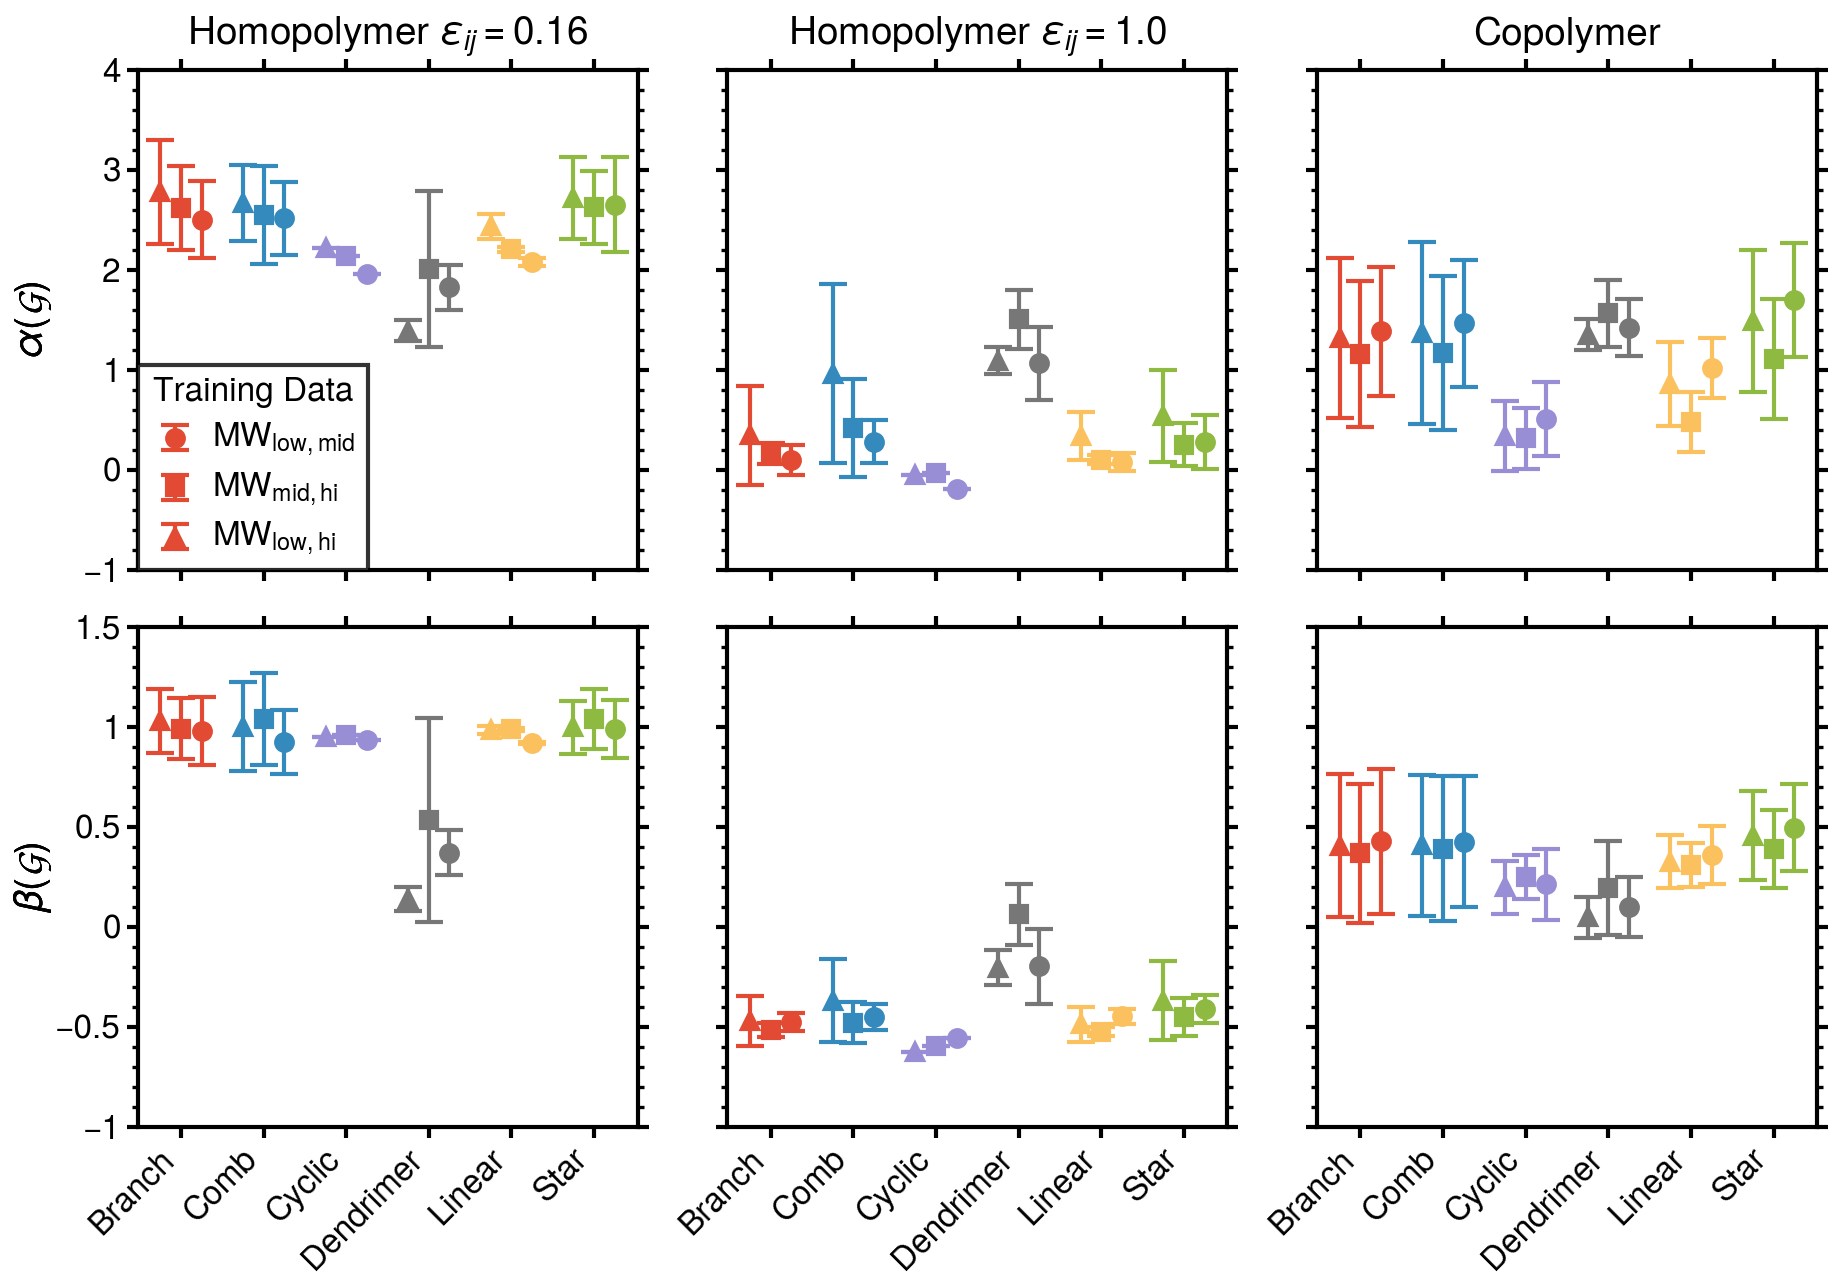

In [8]:
font_big = 14
font_small = 12
lw = 1.5
ncols = 3
nrows = 2

width = 7.5 / ncols
height = width

titles = [r"Homopolymer $\mathit{\varepsilon_{ij}=0.16}$", r"Homopolymer $\mathit{\varepsilon_{ij}=1.0}$", r"Copolymer"]
markers = ['o', 's', '^']
legends = [r'$MW_{low,mid}$', r'$MW_{mid,hi}$', r'$MW_{low,hi}$']
fig, axes = pplt.subplots(nrows=nrows, ncols=ncols, refwidth=width, refheight=height, sharey=True)

for row in range(nrows):
    for split in range(3):
        for ax_idx, pattern in enumerate([0, 1, 2]):
            ax = axes[row, ax_idx]
            unique_topos = np.unique(topologies[split])
            xtick_labels = []

            for topo_idx, topo in enumerate(unique_topos):
                idx = np.where((np.array(topologies[split]) == topo) & 
                               (np.array(patterns[split]) == pattern))[0]
                subset = coeffs[split][row][idx]
                if len(subset) > 0:
                    mean_val = np.mean(subset)
                    std_dev = np.std(subset)
                    x_pos = topo_idx - split * 0.25 - 0.25
                    ax.errorbar(
                        x_pos, mean_val, yerr=std_dev, fmt=markers[split],
                        color=COLORS[topo_idx], label=legends[split] if topo_idx == 0 else None,
                        capsize=5, elinewidth=lw, markeredgewidth=lw
                    )
                    xtick_labels.append(topo.capitalize())

            ax.set_xticks(np.arange(len(unique_topos))-0.5)
            ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

            ax.tick_params(axis='x', which='minor', bottom=False, top=False)
            ax.tick_params(axis='x', which='major', bottom=True, top=True)
            ax.tick_params(axis='y', which='minor', left=True, right=True)
            ax.tick_params(axis='y', which='major', left=True, right=True)
            ax.minorticks_on()
            
            ax.grid()
            ax.format(
                ylim=[-1.0, 1.5] if row == 1 else [-1.0, 4.0],
                xlabelsize=font_big,
                ylabelsize=font_big,
                xticklabelsize=font_small,
                yticklabelsize=font_small,
                title=titles[ax_idx] if row == 0 else None,
                titlesize=font_big,
                tickdir="out",
                linewidth=lw,
            )

            if row == 0 and ax_idx == 0:
                ax.text(
                    -0.25, 0.5, r"$\mathit{\alpha}(\mathcal{G})$", #  or $\mathit{2\nu}$
                    transform=ax.transAxes, rotation=90, fontsize=font_big, 
                    verticalalignment='center'
                )
            elif row == 1 and ax_idx == 0:
                ax.text(
                    -0.25, 0.5, r"$\mathit{\beta}(\mathcal{G})$", 
                    transform=ax.transAxes, rotation=90, fontsize=font_big, 
                    verticalalignment='center'
                )

            if ax_idx == 0 and row == 0:
                legend = ax.legend(ncol=1, title="Training Data")
                legend.get_frame().set_linewidth(lw)
                legend.get_title().set_fontsize(font_small)
                for text in legend.get_texts():
                    text.set_fontsize(font_small)

plt.savefig(PLOT_DIR + "coeff_mw_alpha_beta_std.svg");
